In [1]:
import os
import datetime
from functools import partial

import colormaps
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import xarray as xr
from matplotlib.cm import ScalarMappable
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import MaxNLocator
from pathlib import Path
from tqdm import tqdm
from jetutils.anyspell import get_persistent_jet_spells, mask_from_spells_pl, subset_around_onset, get_persistent_spell_times_from_som, get_spells, extend_spells, gb_index, make_daily
from jetutils.clustering import Experiment, RAW_REALSPACE, labels_to_centers
from jetutils.data import standardize, extract
from jetutils.definitions import DATADIR, KAPPA
from jetutils.jet_finding import gaussian_smooth_func, do_everything, is_polar_gmix
import polars.selectors as cs

os.environ["RUST_BACKTRACE"] = "1"

%load_ext IPython.extensions.autoreload
%autoreload 2
%matplotlib inline

no xgboost found
No shap


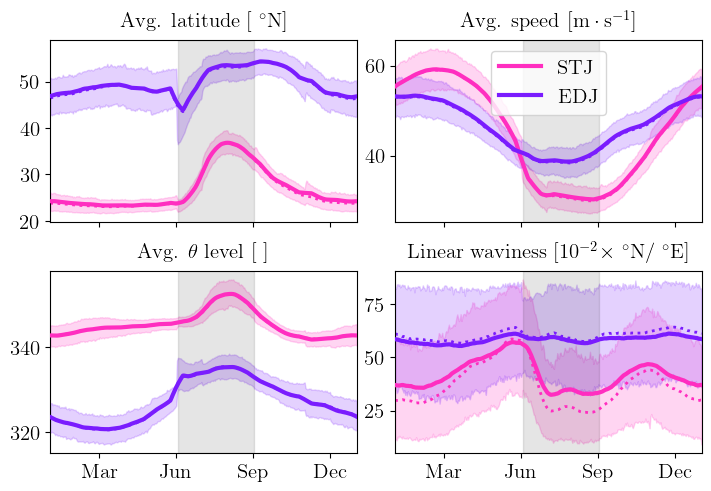

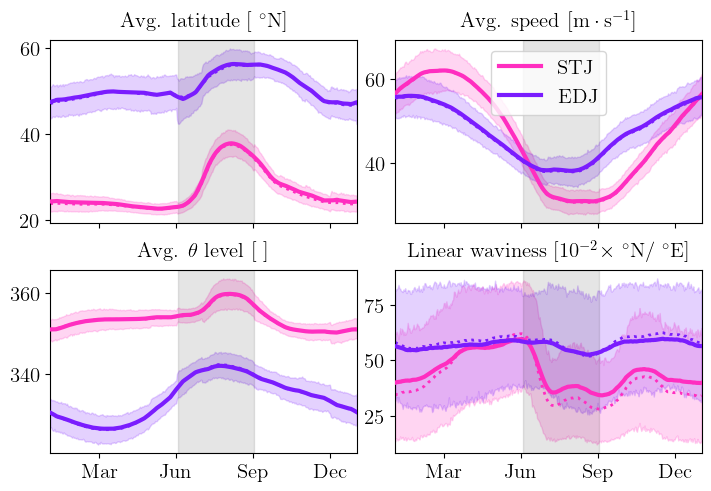

In [ ]:
from jetutils.jet_finding import to_one_large, track_jets, pers_from_cross, average_jet_categories
from jetutils.plots import plot_seasonal

for run in ["historical", "ssp370"]:
    path = Path(DATADIR, "CESM2/high_wind", run, "results/1")
    newpath = Path(DATADIR, "CESM2/high_wind", run, "results/2")
    newpath.mkdir(exist_ok=True)
    jets = pl.read_parquet(path.joinpath("jets_fixed.parquet"))
    jets = jets.drop("diff", "is_polar_old")
    jets.write_parquet(newpath.joinpath("jets.parquet"))
    props = pl.read_parquet(path.joinpath("props.parquet"))
    newcat = jets.group_by("member", "time", "jet ID").agg(pl.col("is_polar").mean())
    props = props.drop("is_polar").join(newcat, on=("member", "time", "jet ID"))
    props.write_parquet(newpath.joinpath("props.parquet"))
    phat_jets = to_one_large(jets, int_EDJ_threshold=1.3e8)
    cross = track_jets(phat_jets)
    cross.write_parquet(newpath.joinpath("cross.parquet"))
    pers = pers_from_cross(cross)    
    phat_filter = (pl.col("is_polar") < 0.5) | ((pl.col("is_polar") > 0.5) & (pl.col("int") > 1.3e8))
    phat_props = props.filter(phat_filter)
    phat_props = average_jet_categories(phat_props, polar_cutoff=0.5)


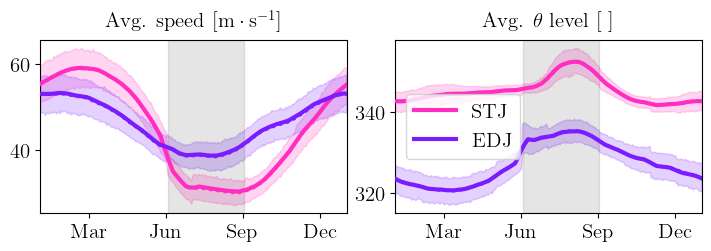

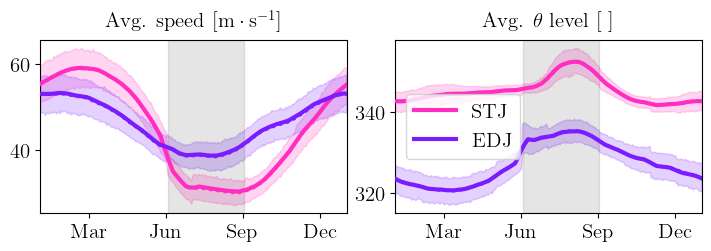

In [ ]:
_ = plot_seasonal(phat_props, ["mean_lat", "mean_s", "mean_theta"], ncols=2, nrows=2, clear=False)

In [9]:
props.drop("is_polar").join(newcat, on=("member", "time", "jet ID"))

member,time,jet ID,mean_lon,mean_lat,mean_lev,mean_theta,mean_s,lon_star,lat_star,s_star,lon_ext,lat_ext,tilt,waviness1,waviness2,wavinessR16,wavinessDC16,wavinessFV15,int,int_over_europe,double_jet_index,width,is_polar
str,datetime[ms],u32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f64
"""r10i1281p1f1""",1975-03-06 12:00:00,1,-59.845638,40.275135,230.267166,330.095703,55.885773,-63.75,45.706806,69.770706,33.75,21.675392,-0.525165,0.365724,2051.501953,0.69808,0.027765,-0.08312,2.59290816e8,0.0,0.0,1.0940e6,0.659884
"""r7i1281p1f1""",1993-07-12 12:00:00,2,-39.398991,70.823547,298.283722,316.690979,38.497128,-50.0,69.267014,50.1143,48.75,21.675388,0.37768,0.177149,1949.698364,0.444623,0.033641,0.072595,1.36673088e8,0.0,1.0,443123.71875,0.679203
"""r8i1251p1f1""",2002-02-27 12:00:00,2,-64.368546,33.361122,224.114441,337.308655,62.489075,-77.5,35.340313,76.146004,32.5,10.366491,-0.253648,0.291544,277.364105,0.318969,0.020946,-0.053404,2.2504648e8,0.0,0.0,983748.375,0.404047
"""r10i1301p1f1""",2001-11-02 12:00:00,2,-40.226131,48.695061,287.091705,321.184967,46.810085,-72.5,52.303665,58.90641,86.25,6.596859,-0.071548,0.36077,360.531311,0.131118,0.019004,-0.000107,3.2165104e8,4.6382716e7,0.837838,851414.5625,0.847109
"""r1i1231p1f1""",2003-10-18 12:00:00,0,-8.286535,22.441746,205.533279,342.830078,28.314318,6.25,26.858639,33.571407,55.0,10.366491,0.225284,0.146555,708.020081,0.239886,0.019011,0.043549,1.73768144e8,9.0115264e7,0.594595,837759.6875,0.249727
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""r4i1251p1f1""",1993-01-29 12:00:00,2,17.198345,65.1064,275.032196,311.478058,44.559704,26.25,63.612564,63.252312,27.5,20.732983,-0.310615,0.878327,2844.190186,18.676821,0.051835,-0.122256,1.80008096e8,1.80008096e8,0.621622,911606.125,0.798512
"""r4i1251p1f1""",1996-09-29 12:00:00,1,-28.189278,56.155357,234.626907,335.183228,53.161198,-38.75,57.958115,74.612946,116.25,18.848171,0.169038,0.104186,3453.552002,0.170242,0.020052,0.056482,4.39409536e8,1.0276128e8,1.0,872922.625,0.778924
"""r9i1161p1f1""",1980-05-22 12:00:00,2,-47.383743,59.315727,286.033539,318.854797,40.783253,-76.25,48.534031,56.152786,81.25,33.926697,0.238328,0.850096,18849.416016,19.636889,0.043794,0.026154,4.66071168e8,2.3814566e7,0.945946,706691.0625,0.860184


In [ ]:
new_is_polar = jets_newcat.group_by("member", "time", "jet ID").agg(pl.col("is_polar").mean())
props_ = props.rename({"is_polar": "is_polar_old"}).join(new_is_polar, on=["member", "time", "jet ID"])

In [ ]:
from jetutils.jet_finding import to_one_large
centers = to_one_large(jets_newcat, int_EDJ_threshold=0).group_by(pl.col("time").dt.week(), "jet").agg(pl.col("theta").mean(), pl.col("s").mean()).sort("time", "jet")

IndexError: index 3 is out of bounds for axis 0 with size 2

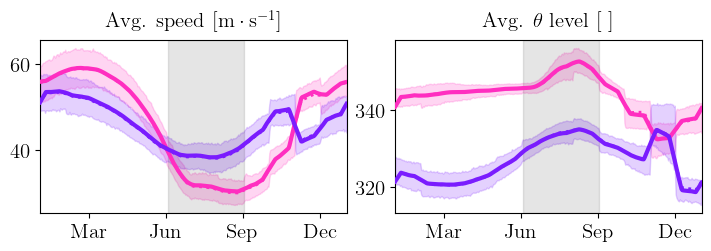

In [ ]:
from jetutils.plots import plot_seasonal
from jetutils.jet_finding import average_jet_categories
_ = plot_seasonal(average_jet_categories(props_), ["mean_s", "mean_theta"], ncols=2, nrows=1, clear=False)

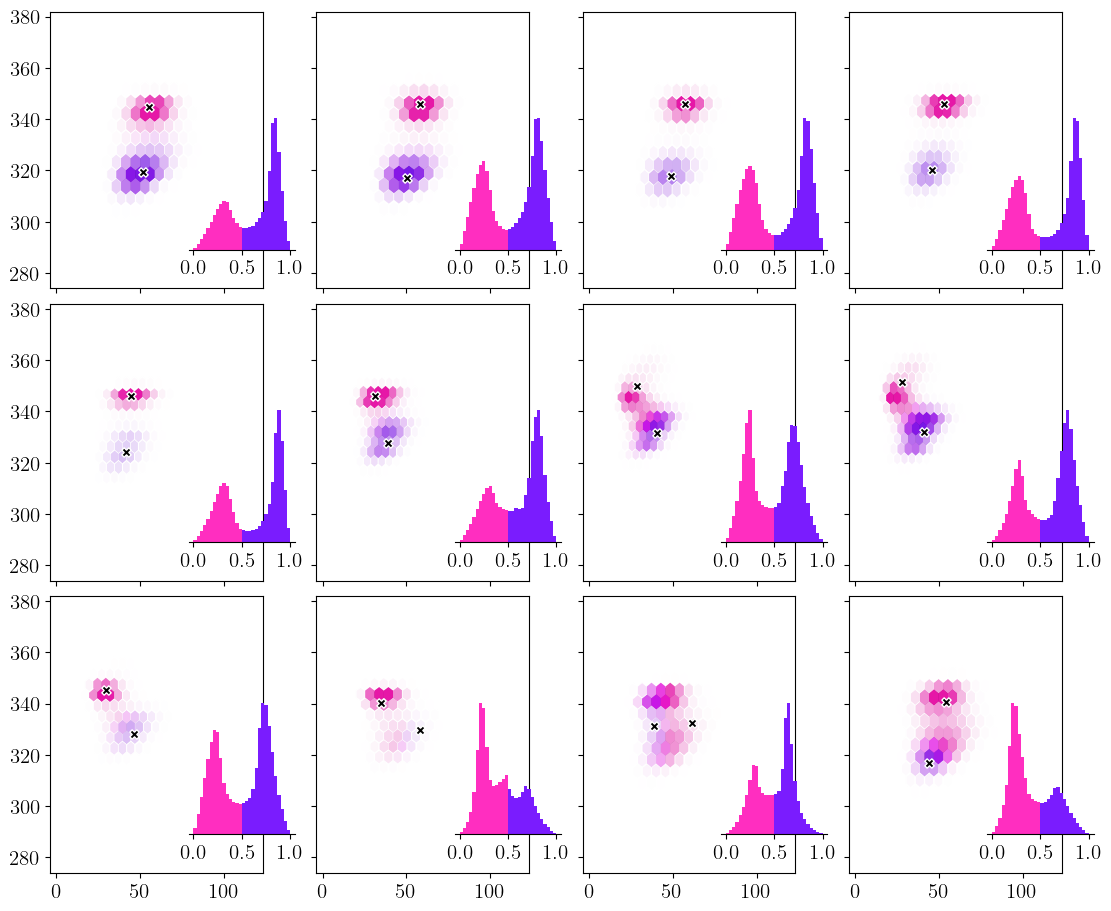

In [84]:
from jetutils.plots import COLORS, COLORS_EXT
from jetutils.definitions import PRETTIER_VARNAME
from matplotlib.colors import hsv_to_rgb, rgb_to_hsv
from jetutils.jet_finding import extract_features
from matplotlib.colors import LinearSegmentedColormap
xys = []
xys = np.array(xys)
fig, axes = plt.subplots(
    3, 4, figsize=(11, 9), constrained_layout=True, sharex="all", sharey="all"
)
axes = axes.ravel()
pair = ["s", "theta", "is_polar"]
cmap = LinearSegmentedColormap.from_list(
    "pinkredpurple", [COLORS[2], COLORS_EXT[8], COLORS[1]]
)
bins = np.linspace(0, 1, 31)
gridsize = 18
for month in range(1, 13):
    ax = axes[month - 1]
    X = extract_features(jets_newcat, pair, season=month)
    probas = X[pair[2]]
    center_stj = X.filter(pl.col("is_polar") < 0.3).mean()
    center_edj = X.filter(pl.col("is_polar") > 0.7).mean()
    X1D = X["is_polar"]

    im1 = ax.hexbin(X[pair[0]], X[pair[1]], cmap=colormaps.gray_r, gridsize=gridsize)
    im2 = ax.hexbin(
        X[pair[0]], X[pair[1]], C=probas, cmap=colormaps.gray_r, gridsize=gridsize
    )

    plt.draw()

    offsets1 = np.asarray(list(map(tuple, im1.get_offsets())), dtype="f, f")
    offsets2 = np.asarray(list(map(tuple, im2.get_offsets())), dtype="f, f")
    mask12 = np.isin(offsets1, offsets2)
    colors = cmap(im2.get_array())
    colors = rgb_to_hsv(colors[:, :3])
    min_s, max_s = 0.0, 0.9
    min_v, max_v = 0.9, 1.0
    scaling = np.clip(
        im1.get_array()[mask12] / im1.get_array()[mask12].max() * 1.1, 0, 1
    )
    f = lambda x: np.pow(x, 2)
    colors[:, 1] = min_s + f(scaling ** 1.5) * (max_s - min_s)
    colors[:, 2] = max_v - f(scaling) * (max_v - min_v)
    colors = hsv_to_rgb(colors)
    im2.set_array(None)
    im2.set_facecolor(colors)
    # im2.set_linewidths(0.2)
    im2.set_linewidths(np.clip(2 - 3 * (scaling), 0, 2))
    im2.set_edgecolor("white")
    im2 = ax.add_collection(im2)
    # if month > 8:
    #     label = PRETTIER_VARNAME.get(pair[0], pair[0])
    #     unit = UNITS.get(pair[0], "$~$")
    #     ax.set_xlabel(f"{label} [{unit}]")
    # if month % 4 == 1:
    #     label = PRETTIER_VARNAME.get(pair[1], pair[1])
    #     unit = UNITS.get(pair[1], "$~$")
    #     ax.set_ylabel(f"{label} [{unit}]")
    # if pair[0] in ["lev", "theta"]:
    #     ax.invert_xaxis()
    # elif pair[1] in ["lev", "theta"]:
    #     ax.invert_yaxis()

    # ax.set_title(MONTH_NAMES[month - 1])
    ax.scatter(
        *pl.concat([center_stj, center_edj])[pair[:2]].to_numpy().T,
        facecolor="black",
        edgecolor="white",
        marker="X",
        linewidths=1,
        s=45,
    )
    iax = ax.inset_axes([0.65, 0.14, 0.5, 0.5])
    X1D = np.clip(X1D, 0, 1)
    iax.hist(X1D, bins=bins, alpha=0.5, color="black")
    iax.hist(X1D[probas > 0.5], bins=bins, alpha=1.0, color=COLORS[1])
    iax.hist(X1D[probas < 0.5], bins=bins, alpha=1.0, color=COLORS[2])
    iax.set_xticks([0, 0.5, 1])
    iax.set_yticks([])
    iax.spines[["left", "right", "top"]].set_visible(False)
    iax.set_facecolor((1.0, 1.0, 1.0, 0.0))
    plt.draw()
    # break
# fig.savefig(f"{FIGURES}/FeatureBased/gmix_demo.pdf")

In [ ]:
import xarray as xr
xr.open_zarr("/storage/workspaces/giub_meteo_impacts/ci01/ERA5/plev/uv/6H/full.zarr").to

In [ ]:
ds = xr.open_zarr(
    'gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3',
    chunks=None,
    storage_options=dict(token='anon'),
)
vars = ["v_component_of_wind", "u_component_of_wind", "vertical_velocity", "temperature"]
levs = [175, 200, 225, 250, 300, 350]
time_filter = (
    np.isin(ds.time.dt.year, np.arange(1959, 2025))
    & (ds.time.dt.hour % 6 == 0)
)
ds = standardize(ds.isel(time=time_filter)[vars]).sel(lev=levs).sel(lon=np.arange(-80, 40.5, 0.5), lat=np.arange(15, 80.5, 0.5))

In [ ]:
to_comp = ds.drop_encoding().to_zarr("/storage/workspaces/giub_meteo_impacts/ci01/ERA5/plev/uv/6H/full.zarr", consolidated=False, compute=False, mode="w")

In [ ]:
from dask.diagnostics.progress import ProgressBar
with ProgressBar():
    to_comp.compute()

# rest

In [ ]:
kwargs = dict(
    n_coarsen=1,
    base_s_thresh=0.55,
    alignment_thresh=0.6,
    int_thresh_factor=0.6,
    hole_size=6,
    smooth_func=partial(gaussian_smooth_func, sigma_lon=2, sigma_lat=0.8),
)

both_jets = {}
both_paths = {}
for run in ["historical", "ssp370"]:
    path = Path(DATADIR, "CESM2/high_wind", run)
    ds = xr.open_dataset(path.joinpath("ds.zarr"))
    ds = standardize(ds)
    ds["theta"] = ds["t"] * (1000 / ds["lev"]) ** KAPPA
    ds = extract(
        ds, minlon=-80, maxlon=40, minlat=15, maxlat=80
    )
    jets, ph_jets, props, props_full = do_everything(ds, path.joinpath("results/1"), feature_names=("s", "theta"), n_init=3, **kwargs)
    both_paths[run] = path
    both_jets[run] = ph_jets